In [1]:
import sys 

sys.path.append("../")

In [2]:
import time 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

from src import ASTPruner, ASTTreeOperator, SqlglotOperator, OntologyOperator, TreeNode

# measures we need to gather in the evaluation process 
- overall time taken for a single query 
- number of nodes in the ast tree
- number of reference nodes in the ast tree 
- policies that used in the query update process 
- rules that used in the query update process 

In [3]:
class Evaluator:
    def __init__(self, ontology_path, agent_id, output_path):
        self.ontology_path = ontology_path
        self.agent_id = agent_id
        self.output_path = output_path

    def compare_trees(self, root1: 'TreeNode', root2: 'TreeNode') -> bool:
        """
        Compares two ASTs for structural and content similarity.
        """

        def _nodes_are_similar(node1: 'TreeNode', node2: 'TreeNode') -> bool:
            """Helper to compare two individual nodes based on the specified rules."""
            if not node1 or not node2:
                return False # Should not happen if called from the main recursion

            # Rule 1: General similarity check for kind and name.
            if node1.kind != node2.kind or node1.name != node2.name:
                return False

            # Rule 2: Special check for TableRef nodes.
            if node1.name == "TableRef":
                id1 = getattr(node1, 'table_reference_id', None)
                id2 = getattr(node2, 'table_reference_id', None)
                if id1 != id2:
                    return False

            # Rule 3: Special check for ColumnRef nodes.
            if node1.name == "ColumnRef":
                id1 = getattr(node1, 'column_reference_id', None)
                id2 = getattr(node2, 'column_reference_id', None)
                if id1 != id2:
                    return False
            
            # If all checks pass, the nodes are similar.
            return True

        def _are_trees_similar_recursive(node1: 'TreeNode', node2: 'TreeNode') -> bool:
            """The main recursive engine for comparing nodes and their subtrees."""
            # Base case: If one node is None and the other isn't, they're not similar.
            if (node1 is None) != (node2 is None):
                return False
            # Base case: If both are None, they are similar.
            if node1 is None and node2 is None:
                return True

            # 1. Compare the current nodes themselves.
            if not _nodes_are_similar(node1, node2):
                return False
            
            # 2. Check if they have the same number of children.
            if len(node1.children) != len(node2.children):
                return False
                
            # 3. Compare the children as unordered sets.
            # This logic ensures that for every child in node1, a matching subtree
            # exists in node2.
            children2_copy = list(node2.children)
            
            for child1 in node1.children:
                found_match = False
                match_index = -1
                for i, child2 in enumerate(children2_copy):
                    # Recursive call: check if the entire subtrees are similar.
                    if _are_trees_similar_recursive(child1, child2):
                        found_match = True
                        match_index = i
                        break # Found a match, move to the next child1.
                
                if not found_match:
                    # If no matching subtree was found for child1, the trees differ.
                    return False
                
                # Remove the matched child so it can't be matched again.
                children2_copy.pop(match_index)
                
            # If all children in node1 found a unique match in node2, the subtrees are similar.
            return True

        # Start the comparison from the root nodes.
        return _are_trees_similar_recursive(root1, root2)
    
    def _string_martching(self, str1, str2):
        """
        A simple string matching function to compare two strings.
        """
        return str1.rstrip(";").strip() == str2.rstrip(";").strip()
    
    def _get_reasoning_stats(self):
        column_ref_instances = self.onto.get_column_ref_instances()
        table_ref_instances = self.onto.get_table_ref_instances()

        # get status 
        policy_set = set()
        rule_set = set()
        for inst in column_ref_instances.values():
            policy_set.add(inst.get('Policy', None))
            rule_set.add(inst.get('Rule', None))
        for inst in table_ref_instances.values():
            policy_set.add(inst.get('Policy', None))
            rule_set.add(inst.get('Rule', None))

        # remove None values
        policy_set.discard(None)
        rule_set.discard(None)
        # convert to list
        # policy_set = list(policy_set)
        # rule_set = list(rule_set)
        return policy_set, rule_set

    def _run_query(self, test_query, expected_query):
        self.onto = OntologyOperator(self.ontology_path)
        start_counter = time.perf_counter()
        # test query update first run 
        test_sql_op = SqlglotOperator(test_query)
        test_tree_op = ASTTreeOperator(test_sql_op)
        self.onto.instantiate_ontology(test_tree_op, self.agent_id)
        self.onto.reason_and_save(self.output_path, save=False)
        pruner = ASTPruner(self.onto)
        pruner.prune()
        output_query = test_sql_op.to_sql(pretty=False)
        print(f"Output query: {output_query}")

        end_counter = time.perf_counter()
        runtime = end_counter - start_counter

        # get run statistics
        ast_stats = self.onto.get_statistics()
        policy_set, rule_set = self._get_reasoning_stats()

        # expected query run 
        print(f"Expected query: {expected_query}")
        if expected_query:
            expected_sql_op = SqlglotOperator(expected_query)
            expected_tree_op = ASTTreeOperator(expected_sql_op)
            self.onto.instantiate_ontology(expected_tree_op, self.agent_id)
        # self.onto.cleanup()

        # test query second run 
        if output_query:
            rerun_sql_op = SqlglotOperator(output_query)
            rerun_tree_op = ASTTreeOperator(rerun_sql_op)
            self.onto.instantiate_ontology(rerun_tree_op, self.agent_id)
            self.onto.reason_and_save(self.output_path, save=False)
            pruner = ASTPruner(self.onto)
            pruner.prune()
            rerun_output_query = rerun_sql_op.to_sql(pretty=False)
            # self.onto.cleanup()
            
            string_matching = True
        else:
            rerun_output_query = None
            rerun_tree_op = None
            string_matching = None
                    
        if not expected_query:
            if not output_query:
                comparison_result = True
                string_matching = None
            else:
                comparison_result = False
                string_matching = self._string_martching(output_query, rerun_output_query)
        else:
            if output_query:
                string_matching = self._string_martching(output_query, rerun_output_query)
                comparison_result = self.compare_trees(expected_tree_op.root, rerun_tree_op.root)
            else:
                comparison_result = False
                string_matching = None

        self.onto.close()
        result_dict = {
            "runtime": runtime,
            "output_query": output_query,
            "rerun_output_query": rerun_output_query,
            "policy_set": policy_set,
            "rule_set": rule_set,
            "update_matching": comparison_result,
            "rerun_matching": string_matching
        }
        result_dict.update(ast_stats)
        return result_dict

    def analyze_query(self, test_query, expected_query, expected_policy_set=None, expected_rule_set=None    ):
        """
        Analyzes the test query against the expected query.
        Returns a dictionary with runtime, policy set, rule set,
        and whether the queries match.
        """
        result_dict = self._run_query(test_query, expected_query)

        # Check if the expected policy set and rule set match the actual ones
        if expected_policy_set is not None:
            result_dict['policy_set_match'] = set(expected_policy_set) == set(result_dict['policy_set'])

        if expected_rule_set is not None:
            result_dict['rule_set_match'] = set(expected_rule_set) == set(result_dict['rule_set'])

        return result_dict
    
    
    def evaluate(self, test_data_path):
        test_df = pd.read_csv(test_data_path).replace({np.nan: None})
        print(test_df.shape)
        # print(test_df.head())
        for row in test_df.itertuples():
            
            print(f"Processing row {row.Index}: {row.input_query} ")
            try:
                result = self.analyze_query(
                    row.input_query, 
                    row.expected_query, 
                    expected_policy_set=row.related_policies, 
                    expected_rule_set=row.related_rules
                )
            except Exception as e:
                result = None
            # Add the result to the DataFrame

            if result:
                for key, value in result.items():
                    if key == 'policy_set' or key == 'rule_set':
                        # Convert set to a sorted list for consistent output
                        value = sorted(value) if value else []
                        # stringify the list for CSV compatibility
                        value = ', '.join(value)
                    test_df.at[row.Index, key] = value

        return test_df

In [4]:
evaluator = Evaluator(ontology_path="../ontology_file/aputv5e.rdf", agent_id="a0012", output_path="")
result_df = evaluator.evaluate(test_data_path="../data/test_dataset_v4.csv")
result_df.to_csv("../data/test_dataset_result_v4r6.csv", index=False)

(99, 8)
Processing row 0: INSERT INTO "Order" (order_id, account_id, k_symbol) VALUES (1, 1, 'SIPO'); 
table entities: {'Card': 't007', 'Disposition': 't005', 'District': 't008', 'Order': 't001', 'Transaction': 't002', 'Account': 't003', 'Loan': 't004', 'Client': 't006', 'xxxxx': 't00x'}
column lookup: {('xxxxx', 'ooooo'): 'c00x', ('Card', 'type'): 'c026', ('Order', 'order_id'): 'c001', ('Order', 'account_to'): 'c004', ('Order', 'k_symbol'): 'c006', ('Transaction', 'trans_id'): 'c007', ('Loan', 'loan_id'): 'c016', ('Card', 'disp_id'): 'c020', ('Disposition', 'disp_id'): 'c020', ('Disposition', 'client_id'): 'c021', ('Client', 'client_id'): 'c021', ('Card', 'card_id'): 'c025', ('Transaction', 'k_symbol'): 'c032', ('Disposition', 'account_id'): 'c002', ('Order', 'account_id'): 'c002', ('Transaction', 'account_id'): 'c002', ('Account', 'account_id'): 'c002', ('Loan', 'account_id'): 'c002', ('Client', 'account_id'): 'c002', ('Order', 'amount'): 'c005', ('Transaction', 'date'): 'c008', ('Tr

* Owlready2 * Running Pellet...
    java -Xmx2000M -cp c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\jena-arq-2.10.0.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\jena-core-2.10.0.jar;c:\Use

* Owlready * Adding relation aputv5e.s8fe3ec hasChildNode aputv5e.nd8c019
* Owlready * Adding relation aputv5e.s8fe3ec hasChildNode aputv5e.n127586
* Owlready * Adding relation aputv5e.s8fe3ec hasChildNode aputv5e.n8fe3ec
* Owlready * Adding relation aputv5e.s8fe3ec hasChildNode aputv5e.ne0f40c
* Owlready * Adding relation aputv5e.s8fe3ec hasChildNode aputv5e.nec707a
* Owlready * Adding relation aputv5e.s8fe3ec hasChildNode aputv5e.n5f4e58
* Owlready * Adding relation aputv5e.s8fe3ec hasChildNode aputv5e.n458144
* Owlready * Adding relation aputv5e.s8fe3ec hasChildNode aputv5e.n1a3831
* Owlready * Adding relation aputv5e.s8fe3ec immediateChildNode aputv5e.n8fe3ec
* Owlready * Adding relation aputv5e.s8fe3ec immediateChildNode aputv5e.n458144
* Owlready * Adding relation aputv5e.n458144 hasParentNode aputv5e.s8fe3ec
* Owlready * Adding relation aputv5e.n458144 immediateParentNode aputv5e.s8fe3ec
* Owlready * Adding relation aputv5e.n458144 hasChildNode aputv5e.nd8c019
* Owlready * Addin

* Owlready2 * Pellet took 2.1539807319641113 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)
* Owlready2 * Running Pellet...
    java -Xmx2000M -cp c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib

--- Starting AST Pruning Process ---
Query before pruning: INSERT INTO "Order" (order_id, account_id, k_symbol) VALUES (1, 1, 'SIPO')
--> Stage 1: Pruning based on table statuses...
 Parent clause name: InsertClause and kind: Clause | Instance: n1a3831
>> Instance: n1a3831
>>> Instance: n1a3831
Output query: None
Expected query: None
Processing row 1: UPDATE "Client" SET gender = 'female' WHERE client_id = 10; 
table entities: {'Card': 't007', 'Disposition': 't005', 'District': 't008', 'Order': 't001', 'Transaction': 't002', 'Account': 't003', 'Loan': 't004', 'Client': 't006', 'xxxxx': 't00x'}
column lookup: {('xxxxx', 'ooooo'): 'c00x', ('Card', 'type'): 'c026', ('Order', 'order_id'): 'c001', ('Order', 'account_to'): 'c004', ('Order', 'k_symbol'): 'c006', ('Transaction', 'trans_id'): 'c007', ('Loan', 'loan_id'): 'c016', ('Card', 'disp_id'): 'c020', ('Disposition', 'disp_id'): 'c020', ('Disposition', 'client_id'): 'c021', ('Client', 'client_id'): 'c021', ('Card', 'card_id'): 'c025', ('T

...

* Owlready2 * Pellet took 2.6008965969085693 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)
* Owlready2 * Running Pellet...
    java -Xmx2000M -cp c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib

--- Starting AST Pruning Process ---
Query before pruning: SELECT SUM(amount) AS total_amount, status FROM "Loan" AS l WHERE l.amount > 100000 AND l.duration > 60
--> Stage 1: Pruning based on table statuses...
--> Stage 2: Pruning based on column statuses...
     - Initial violated column IDs: []
     - No violated columns found.
Output query: SELECT SUM(amount) AS total_amount, status FROM "Loan" AS l WHERE l.amount > 100000 AND l.duration > 60
Expected query: SELECT Sum(amount) as total_amount, status FROM "Loan" l WHERE l.amount > 100000 AND l.duration > 60;
--> Instantiating ontology individuals...
SELECT SUM(amount) AS total_amount, status FROM "Loan" AS l WHERE l.amount > 100000 AND l.duration > 60
Found 1 FROM/Join nodes in statement sa4d27b.
Initial in-context sources: {'Loan': {'type': 'base_table', 'name': 'Loan'}, 'l': {'type': 'base_table', 'name': 'Loan'}}
Resolving column 'amount' in context of table alias 'None' | context_sources: {'Loan': {'type': 'base_table', 'name':

* Owlready2 * Pellet took 2.5062096118927 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)
* Owlready2 * Running Pellet...
    java -Xmx2000M -cp c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\si

* Owlready * Adding relation aputv5e.n09427a hasParentNode aputv5e.s5858c6
* Owlready * Adding relation aputv5e.n09427a hasParentNode aputv5e.n5858c6
* Owlready * Adding relation aputv5e.n09427a immediateParentNode aputv5e.n5858c6
* Owlready * Adding relation aputv5e.n09427a hasChildNode aputv5e.n46e2ff
* Owlready * Adding relation aputv5e.n09427a hasChildNode aputv5e.nb6e6e3
* Owlready * Adding relation aputv5e.n00d544 hasParentNode aputv5e.nde1925
* Owlready * Adding relation aputv5e.n00d544 hasParentNode aputv5e.n11c2c2
* Owlready * Adding relation aputv5e.n00d544 hasParentNode aputv5e.s5858c6
* Owlready * Adding relation aputv5e.n00d544 hasChildNode aputv5e.n62476d
* Owlready * Adding relation aputv5e.n00d544 hasChildNode aputv5e.n0c72eb
* Owlready * Adding relation aputv5e.nde1925 hasParentNode aputv5e.s5858c6
* Owlready * Adding relation aputv5e.nde1925 immediateParentNode aputv5e.s5858c6
* Owlready * Adding relation aputv5e.nde1925 hasChildNode aputv5e.n11c2c2
* Owlready * Addin

* Owlready2 * Pellet took 2.577789306640625 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)


In [5]:
result_df.head()

,query_id,input_query,Correct,expected_query,related_policies,related_rules,complexity,Overall Validation Status,runtime,output_query,...,rule_set,update_matching,rerun_matching,total_instances,table_refs,column_refs,table_entities,column_lookup,policy_set_match,rule_set_match
0,q001,"INSERT INTO ""Order"" (order_id, account_id, k_s...",Yes,None,p002,rtm,Simple,Prohibited,4.489501,None,...,rtm,True,None,9.0,1.0,0.0,9.0,43.0,False,False
1,q002,"UPDATE ""Client"" SET gender = 'female' WHERE cl...",Yes,None,p003,rtm,Simple,Prohibited,4.746509,None,...,rtm,True,None,10.0,1.0,2.0,9.0,43.0,False,False
2,q003,"DELETE FROM ""Card"" WHERE card_id = 15;",Yes,None,p004,rtm,Simple,Prohibited,4.602975,None,...,rtm,True,None,7.0,1.0,1.0,9.0,43.0,False,False
3,q004,"SELECT * FROM ""Disposition"";",Yes,None,"p001, p005, p006","rcp, rcv, rtr",Simple,Prohibited,4.812656,None,...,"rcp, rcv, rtr",True,None,8.0,1.0,4.0,9.0,43.0,False,False
4,q005,"SELECT account_id, district_id FROM ""Account"";",No,None,p006,rcv,Simple,Prohibited,4.890958,None,...,rcv,True,None,6.0,1.0,2.0,9.0,43.0,False,False


---

In [6]:
def get_policy_hit_rate(detected_policies, expected_policies):
    """
    Calculate the hit rate of detected policies against expected policies.
    """
    if not expected_policies:
        return 0.0 if detected_policies else 1.0
    
    # convert string into list 
    detected_policies = detected_policies.split(", ")
    expected_policies = expected_policies.split(", ")

    hit_count = sum(1 for policy in detected_policies if policy in expected_policies)
    return hit_count / len(detected_policies) if expected_policies else 0.0

def get_rule_hit_rate(detected_rules, expected_rules):
    """
    Calculate the hit rate of detected rules against expected rules.
    """
    if expected_rules == "":
        return 1.0 if detected_rules == "" else 0.0
    
    # convert string into list 
    detected_rules = detected_rules.split(", ")
    expected_rules = expected_rules.split(", ")

    hit_count = sum(1 for rule in detected_rules if rule in expected_rules)
    return hit_count / len(detected_rules) if expected_rules else 0.0

def get_conditional_hit_rate(detected_conditions, expected_conditions):
    """
    Calculate the hit rate of detected conditions against expected conditions.
    """
    if expected_conditions == "":
        return 1.0 if detected_conditions == "" else 0.0
    
    # convert string into list 
    detected_conditions = detected_conditions.split(", ")
    expected_conditions = expected_conditions.split(", ")

    hit_count = sum(1 for condition in detected_conditions if condition in expected_conditions)
    return hit_count / len(expected_conditions) if expected_conditions else 0.0

def get_performance_metrics(result_df):
    """
    Calculate performance metrics from the result DataFrame.
    """
    result_df['rerun_matching'] = pd.to_numeric(result_df['rerun_matching'], errors='coerce')
    result_df['update_matching'] = pd.to_numeric(result_df['update_matching'], errors='coerce')
    metrics = {
        "avg_runtime": result_df['runtime'].mean(),
        "avg_policy_hit_rate": result_df.apply(
            lambda row: get_policy_hit_rate(row['policy_set'], row['related_policies']), axis=1
        ).mean(),
        "avg_rule_hit_rate": result_df.apply(
            lambda row: get_rule_hit_rate(row['rule_set'], row['related_rules']), axis=1
        ).mean(),
        "avg_conditional_hit_rate": result_df.apply(
            lambda row: get_conditional_hit_rate(row['policy_set'], row['related_policies']), axis=1
        ).mean(),
        "update_matching_rate": result_df['update_matching'].mean(),
        "rerun_matching_rate": result_df['rerun_matching'].mean()
    }
    return metrics

def plot_runtime_distribution(result_df):
    """
    Plot a scatter plot with polynormial regression line for runtime distribution.
    Comparing total reference nodes vs runtime
    """
    # Prepare data for polynomial regression
    result_df['total_reference_nodes'] = result_df['table_refs'] + result_df['column_refs']
    X = result_df['total_reference_nodes'].values.reshape(-1, 1)
    y = result_df['runtime'].values

    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    # Generate predictions for the polynomial regression line
    X_new = np.linspace(result_df['total_reference_nodes'].min(), result_df['total_reference_nodes'].max(), 200).reshape(200, 1)
    X_new_poly = poly.transform(X_new)
    y_new = model.predict(X_new_poly)
    # y_pred = model.predict(X_poly)

    # Plotting
    plt.figure(figsize=(10, 4))
    sns.scatterplot(x='total_reference_nodes', y='runtime', data=result_df, label='Data Points')
    plt.plot(X_new, y_new, color='red', label='Polynomial Regression Line')
    
    # plt.title('Runtime Distribution with Polynomial Regression')
    plt.xlabel('Total Reference Nodes')
    plt.ylabel('Runtime (seconds)')
    plt.legend()
    plt.show()

def total_llm_accuracy(test_df):
    """
    Calculate the total accuracy of the LLM based on the test DataFrame.
    """
    # Count the number of rows where 'update_matching' is True
    total_rows = len(test_df)
    if total_rows == 0:
        return 0.0
    
    # total accuracy
    correct_updates = (test_df['Correct'] == "Yes").sum()
    accuracy = correct_updates / total_rows * 100
    # permitted accuracy
    permitted_queries = test_df.loc[test_df['Overall Validation Status'] == "Permitted", :]
    current_permitted_rows = (permitted_queries['Correct'] == "Yes").sum()
    permitted_accuracy = current_permitted_rows / len(permitted_queries) * 100 if len(permitted_queries) > 0 else 0.0

    prohibited_queries = test_df.loc[test_df['Overall Validation Status'] == "Prohibited", :]
    current_prohibited_rows = (prohibited_queries['Correct'] == "Yes").sum()
    prohibited_accuracy = current_prohibited_rows / len(prohibited_queries) * 100 if len(prohibited_queries) > 0 else 0.0
    return {
        "total_accuracy": accuracy,
        "permitted_accuracy": permitted_accuracy,
        "prohibited_accuracy": prohibited_accuracy}

In [7]:
result_df = pd.read_csv("../data/test_dataset_result_v4r6.csv")
result_df.fillna('', inplace=True)  # Fill NaN values with empty strings for string operations
result_df.head()

,query_id,input_query,Correct,expected_query,related_policies,related_rules,complexity,Overall Validation Status,runtime,output_query,...,rule_set,update_matching,rerun_matching,total_instances,table_refs,column_refs,table_entities,column_lookup,policy_set_match,rule_set_match
0,q001,"INSERT INTO ""Order"" (order_id, account_id, k_s...",Yes,,p002,rtm,Simple,Prohibited,4.489501,,...,rtm,True,,9.0,1.0,0.0,9.0,43.0,False,False
1,q002,"UPDATE ""Client"" SET gender = 'female' WHERE cl...",Yes,,p003,rtm,Simple,Prohibited,4.746509,,...,rtm,True,,10.0,1.0,2.0,9.0,43.0,False,False
2,q003,"DELETE FROM ""Card"" WHERE card_id = 15;",Yes,,p004,rtm,Simple,Prohibited,4.602975,,...,rtm,True,,7.0,1.0,1.0,9.0,43.0,False,False
3,q004,"SELECT * FROM ""Disposition"";",Yes,,"p001, p005, p006","rcp, rcv, rtr",Simple,Prohibited,4.812656,,...,"rcp, rcv, rtr",True,,8.0,1.0,4.0,9.0,43.0,False,False
4,q005,"SELECT account_id, district_id FROM ""Account"";",No,,p006,rcv,Simple,Prohibited,4.890958,,...,rcv,True,,6.0,1.0,2.0,9.0,43.0,False,False


In [8]:
total_llm_accuracy(result_df)

{'total_accuracy': np.float64(34.34343434343434),
 'permitted_accuracy': np.float64(25.49019607843137),
 'prohibited_accuracy': np.float64(43.75)}

In [9]:
get_performance_metrics(result_df)

{'avg_runtime': np.float64(5.434414774746689),
 'avg_policy_hit_rate': np.float64(1.0),
 'avg_rule_hit_rate': np.float64(1.0),
 'avg_conditional_hit_rate': np.float64(1.0),
 'update_matching_rate': np.float64(1.0),
 'rerun_matching_rate': np.float64(1.0)}

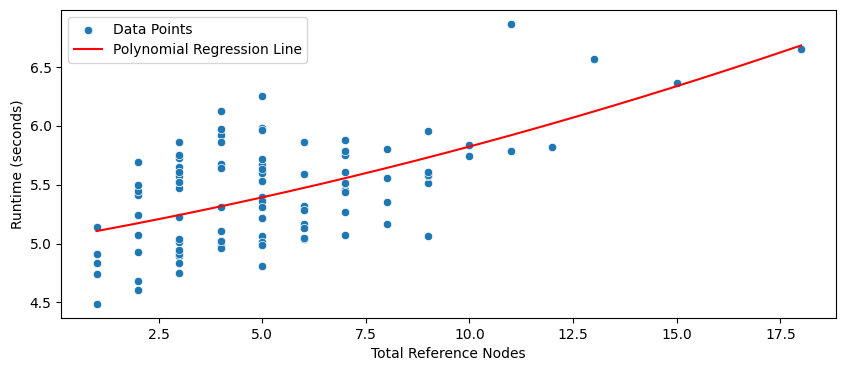

In [10]:
plot_runtime_distribution(result_df)